# Polly mvp2 — Realistic, Bankroll-Managed Copy-Trading

mvp1 asked *"is copying top traders profitable?"* and found naive copying ≈ break-even
out-of-sample. It had two acknowledged flaws this notebook fixes:

1. **Unrealistic information flow** — fills were priced at the *leader's own* price with a
   flat 2% slippage and zero latency.
2. **No bankroll management** — every bet was a flat \$1.

**What mvp2 changes** (all grounded in the deep-research reports in `../../research/`):

| Area | mvp1 | mvp2 |
|---|---|---|
| Fill price | leader's price + flat 2% | **price of the next real trade at `t+Δ`** (latency-aware) reconstructed from the trade tape |
| Costs | none | **category taker fee** `fee = size·rate·p·(1−p)` |
| Win prob | implicit | **price-calibrated on train, shrunk toward the market price** (efficient prior) |
| Sizing | \$1 flat | **fractional-Kelly** `f*=(p−c)/(1−c)` on a **compounding bankroll**, per-bet/per-event/aggregate caps |
| Validation | one 60/20/20 split | **purged walk-forward** folds + **Deflated Sharpe** (multiple-testing guard) |
| Reporting | per-bet ROI | **daily/monthly/yearly returns, Sharpe/Sortino/Calmar, max drawdown** |

> ⚠️ **Survivorship caveat, stated up front.** The cohort is the *current* top-100 leaderboard —
> i.e. selected *because* it won. That bias lives on the **trader axis**, which a time-based
> walk-forward cannot remove. So nominal bankroll returns below are an **upper bound, not a
> forward estimate**; we lean on the **Deflated Sharpe Ratio** and the **per-fold time trend**
> to judge what is actually robust.

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import fills, signals, bankroll, evaluation as ev, backtest as bt
sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi']=110
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print('modules loaded')

modules loaded


## 1 · The realistic fill model (and what latency + fees actually cost)

A *copyable bet* is a cohort BUY on a resolved market. The copier buys the same token and
holds to resolution. Instead of the leader's price, we use the **price of the next real
trade at `t+Δ`** (reconstructed from the dense trade tape, since historical books aren't
retrievable), then subtract the category taker fee. We compare the mvp1-style fill to the
mvp2 realistic fill **on the same bet set**.

In [2]:
raw = fills.load_buys()
print(f'copyable BUYs: {len(raw):,} | traders: {raw.proxyWallet.nunique()} | markets: {raw.conditionId.nunique()}')
# mvp1-style: leader price, no fee
m1 = fills.price_after_fees(fills.reconstruct_fill(raw, 0).assign(fee_rate=0.0))
# latency sweep, fees on; compare on bets fillable at the largest delta (constant set)
rows=[]
fillsets={}
for d in [0,10,30,60,300,900]:
    f = fills.price_after_fees(fills.reconstruct_fill(raw, d))
    fillsets[d]=f
common = fillsets[900]['fillable'].values
for d,f in fillsets.items():
    sub=f[common]
    rows.append({'delta_s':d,'n':int(common.sum()),'mean_roi':sub['roi'].mean(),
                 'win_rate':sub['payout'].mean(),'avg_fee_per_share':sub['fee_per_share'].mean()})
sweep=pd.DataFrame(rows); display(sweep)
print(f"mvp1-style per-bet ROI (leader price, no fee): {m1['roi'].mean():+.4f}")
print(f"mvp2 realistic per-bet ROI (Δ=30s + fees)    : {fillsets[30]['roi'].mean():+.4f}")

copyable BUYs: 67,067 | traders: 88 | markets: 1559


,delta_s,n,mean_roi,win_rate,avg_fee_per_share
0,0,41358,0.4036,0.6754,0.0073
1,10,41358,0.4014,0.6754,0.0073
2,30,41358,0.4038,0.6754,0.0073
3,60,41358,0.4080,0.6754,0.0072
4,300,41358,0.4178,0.6754,0.0072
5,900,41358,0.4343,0.6754,0.0072


mvp1-style per-bet ROI (leader price, no fee): +0.3964
mvp2 realistic per-bet ROI (Δ=30s + fees)    : +0.3940


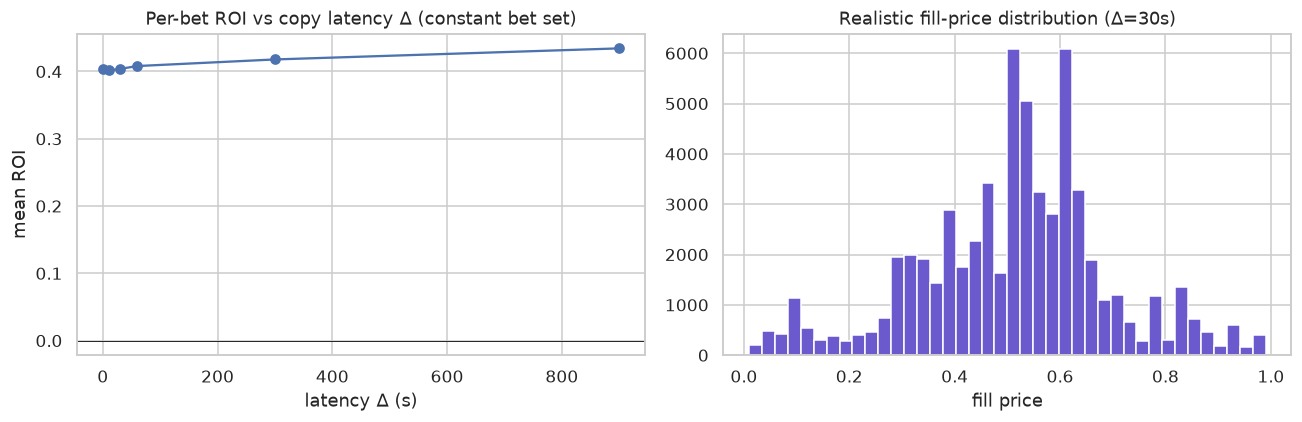

In [3]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(sweep['delta_s'],sweep['mean_roi'],'o-'); ax[0].set(title='Per-bet ROI vs copy latency Δ (constant bet set)',xlabel='latency Δ (s)',ylabel='mean ROI'); ax[0].axhline(0,color='k',lw=.6)
f30=fillsets[30][fillsets[30]['fillable']]
ax[1].hist(f30['fill_price'],bins=40,color='slateblue'); ax[1].set(title='Realistic fill-price distribution (Δ=30s)',xlabel='fill price')
plt.tight_layout(); plt.show()

## 2 · Win-probability calibration — and the survivorship signature

We calibrate the win rate by entry-price bucket on training data. **If the cohort had no
edge, calibrated win rate ≈ price (the diagonal).** Instead it sits far *above* price — the
fingerprint of survivorship (we picked winners). That is exactly why we then **shrink the
estimate toward the market price** before sizing, and why we trust the Deflated Sharpe over
the nominal return.

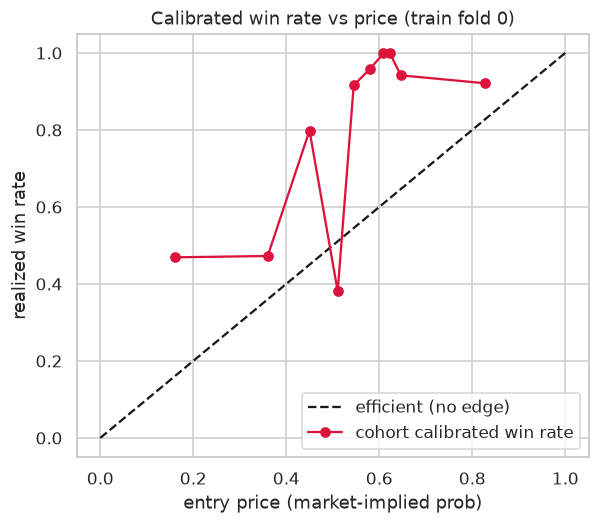

Brier score of price-calibrated p on test fold 0: 0.268 (lower=better; 0.25=coin flip)


In [4]:
buys = bt.base_buys(delta_s=30)
folds = ev.walk_forward_folds(buys, n_folds=5)
tr0, te0 = folds[0]
f_cal, tab = signals.calibrate_by_price(tr0)
cal = pd.DataFrame(tab)
fig,ax=plt.subplots(figsize=(6,5))
ax.plot([0,1],[0,1],'k--',label='efficient (no edge)')
ax.plot((cal['lo']+cal['hi'])/2, cal['p'],'o-',color='crimson',label='cohort calibrated win rate')
ax.set(title='Calibrated win rate vs price (train fold 0)',xlabel='entry price (market-implied prob)',ylabel='realized win rate'); ax.legend(); plt.show()
br = signals.brier_score(f_cal(te0['fill_price']), te0['payout'])
print(f'Brier score of price-calibrated p on test fold 0: {br:.3f} (lower=better; 0.25=coin flip)')

## 3 · The honest signal: per-fold realized ROI is unstable and fades

Before any sizing, look at the raw realistic per-bet ROI in each **walk-forward test window**.
A robust edge would be consistently positive. Instead it swings violently and the **most
recent fold is negative** — echoing mvp1's −0.1% test and the independent live copy-bot's
−2.47% (see `../../research/`).

,fold,test_start,n_bets,mean_roi,win_rate,avg_price
0,0,2026-05-01 21:26:44+00:00,7371,0.0022,0.4948,0.5117
1,1,2026-06-06 12:56:09+00:00,7369,1.3570,0.7492,0.5070
2,2,2026-06-15 22:29:55+00:00,7371,0.5955,0.8266,0.5096
3,3,2026-06-20 16:47:26+00:00,7370,0.0208,0.4582,0.4395
4,4,2026-06-22 06:14:25+00:00,7370,-0.1516,0.4682,0.5189


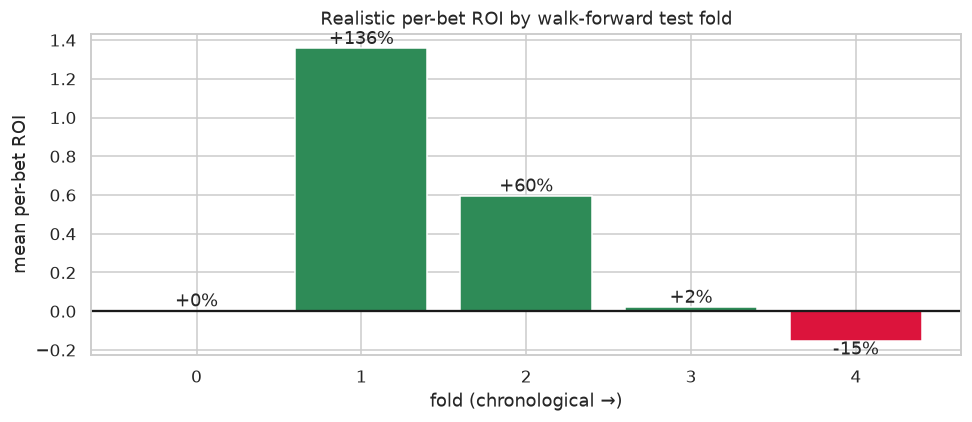

In [5]:
rows=[]
for k,(trn,te) in enumerate(folds):
    rows.append({'fold':k,'test_start':pd.to_datetime(te.entry_ts.min(),unit='s',utc=True),
                 'n_bets':len(te),'mean_roi':te['roi'].mean(),'win_rate':te['payout'].mean(),
                 'avg_price':te['fill_price'].mean()})
foldtbl=pd.DataFrame(rows); display(foldtbl)
fig,ax=plt.subplots(figsize=(9,4))
colors=['seagreen' if v>=0 else 'crimson' for v in foldtbl['mean_roi']]
ax.bar(foldtbl['fold'],foldtbl['mean_roi'],color=colors)
ax.axhline(0,color='k'); ax.set(title='Realistic per-bet ROI by walk-forward test fold',xlabel='fold (chronological →)',ylabel='mean per-bet ROI')
for i,v in zip(foldtbl['fold'],foldtbl['mean_roi']): ax.text(i,v,f'{v:+.0%}',ha='center',va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()

## 4 · Bankroll simulation (fractional Kelly, compounding)

Now size each copy with **¼-Kelly** on the shrunk win probability, compounding a \$10k bankroll
across purged walk-forward folds, with per-bet (3%), per-event (10%) and aggregate (30%) caps.
We report the full metrics suite. **Read the Deflated Sharpe and max drawdown, not the nominal
return** — the latter is survivorship/windfall-inflated.

In [6]:
fb = buys['payout'].mean()
strategies = {
 'copy-all':     lambda tr,te: bt.attach_winprob_copyall(tr,te,shrink=0.5),
 'follow-skill': lambda tr,te: bt.attach_winprob_skill(tr,te,top_frac=0.5,shrink=0.5),
 'consensus>=3': lambda tr,te: bt.attach_winprob_consensus(tr,te,3,fb,shrink=0.5),
 'consensus>=5': lambda tr,te: bt.attach_winprob_consensus(tr,te,5,fb,shrink=0.5),
}
res={}; rows=[]
for name,fn in strategies.items():
    r=bt.run_strategy(buys,fn,kelly_frac=0.25); res[name]=r
    m=r['metrics']
    rows.append({'strategy':name,'n_bets':m['n_bets'],'roi_total':m['roi_total'],
                 'max_drawdown':m['max_drawdown'],'sharpe':m['sharpe'],'calmar':m['calmar'],
                 'win_rate':m['win_rate'],'deflated_sharpe':m['deflated_sharpe'],
                 'final_$':m['bankroll_final']})
summary=pd.DataFrame(rows).set_index('strategy'); display(summary)
print('Deflated Sharpe > 0.95 would indicate significance after multiple-testing correction.')

,n_bets,roi_total,max_drawdown,sharpe,calmar,win_rate,deflated_sharpe,final_$
strategy,,,,,,,,
copy-all,826,13.4819,-0.5395,4.8136,"185,286,826.6339",0.6017,0.6007,"146,178.1381"
follow-skill,191,3.1320,-0.5324,6.4593,"59,634,780.6214",0.6178,0.1974,"41,319.9715"
consensus>=3,35,1.1253,-0.0300,9.8684,"323,058.6338",0.7429,0.9103,"21,253.4259"
consensus>=5,6,0.2538,0.0000,5.6583,NaN,0.8333,0.1919,"12,538.2893"


Deflated Sharpe > 0.95 would indicate significance after multiple-testing correction.


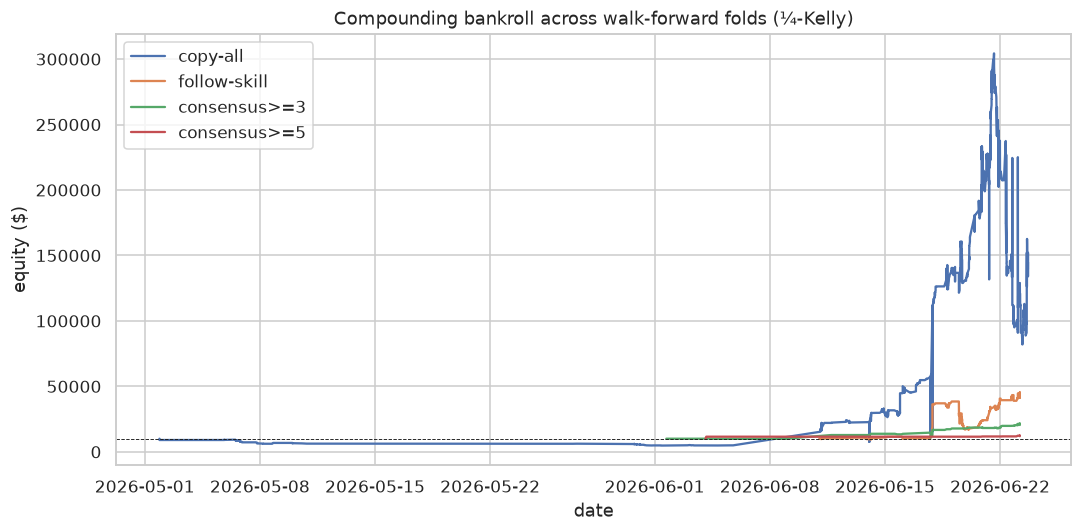

In [7]:
fig,ax=plt.subplots(figsize=(10,5))
for name,r in res.items():
    if r is None: continue
    eq=r['equity'].set_index('datetime')['equity']
    ax.plot(eq.index, eq.values/r['metrics'].get('bankroll_final',1)*0+eq.values, label=name)
ax.set(title='Compounding bankroll across walk-forward folds (¼-Kelly)',ylabel='equity ($)',xlabel='date'); ax.axhline(10000,color='k',lw=.6,ls='--'); ax.legend(); plt.tight_layout(); plt.show()

## 5 · Risk control: the fractional-Kelly drawdown law

Theory (MacLean–Thorp–Ziemba): under fraction `f` of full Kelly, the probability of ever
drawing down to fraction `a` of bankroll is ≈ `a^(1/f)` — so fractional Kelly sharply cuts
drawdowns. We verify the direction empirically on the consensus strategy.

In [8]:
rows=[]
for kf in [1.0,0.5,0.25,0.125]:
    r=bt.run_strategy(buys, lambda tr,te: bt.attach_winprob_consensus(tr,te,3,fb,shrink=0.5), kelly_frac=kf)
    if r: rows.append({'kelly_fraction':kf,'roi_total':r['metrics']['roi_total'],
                       'max_drawdown':r['metrics']['max_drawdown'],'final_$':r['metrics']['bankroll_final']})
kelly=pd.DataFrame(rows); display(kelly)
print('Smaller Kelly fraction -> shallower drawdown (a^(1/f) law), at the cost of growth.')

,kelly_fraction,roi_total,max_drawdown,final_$
0,1.0000,1.2078,-0.0300,"22,077.5693"
1,0.5000,1.1824,-0.0300,"21,823.8597"
2,0.2500,1.1253,-0.0300,"21,253.4259"
3,0.1250,0.9514,-0.0300,"19,514.0603"


Smaller Kelly fraction -> shallower drawdown (a^(1/f) law), at the cost of growth.


## 6 · H2 — does edge concentrate in *slower* markets?

The microstructure research predicts fast informed-flow alpha decays before a copier can act,
so any surviving edge should favour longer-horizon markets. We split realistic per-bet ROI by
category (Sports = fast/short-dated; Politics/Crypto = slower).

,n,mean_roi,win
category,,,
Sports,45507,0.2888,0.6181
Politics,14297,0.8458,0.8921
Other,997,-0.9976,0.0020
Crypto,359,0.3121,0.7409
Geopolitics,128,-0.5638,0.2969
Finance,64,-0.7467,0.2031
Tech,54,-0.6893,0.2593
Culture,13,-0.9205,0.0769


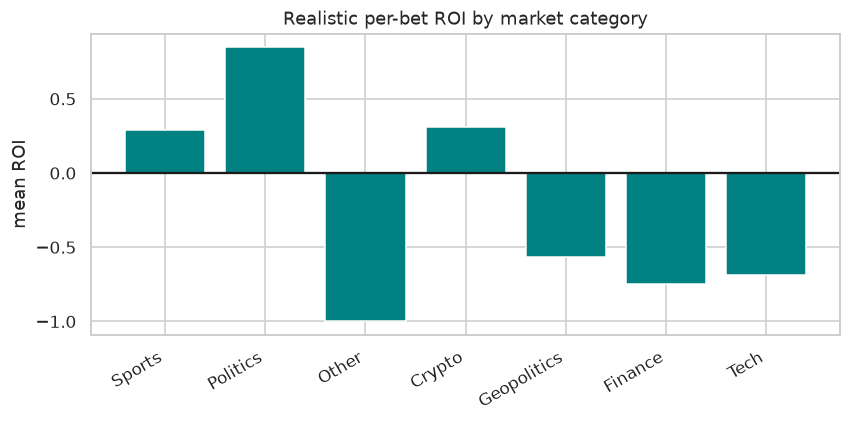

In [9]:
cat = buys.groupby('category').agg(n=('roi','size'),mean_roi=('roi','mean'),win=('payout','mean')).sort_values('n',ascending=False)
display(cat)
fig,ax=plt.subplots(figsize=(8,4)); c=cat[cat['n']>=50]
ax.bar(c.index,c['mean_roi'],color='teal'); ax.axhline(0,color='k'); ax.set(title='Realistic per-bet ROI by market category',ylabel='mean ROI'); plt.xticks(rotation=30,ha='right'); plt.tight_layout(); plt.show()

## 7 · Auto-generated findings

In [10]:
recent = foldtbl.iloc[-1]
ca = summary.loc['copy-all']
print('AUTO-GENERATED FINDINGS'); print('-'*64)
print(f"1. Latency+fees cost only {(m1['roi'].mean()-fillsets[30]['roi'].mean())*100:.1f} pts of full-sample per-bet ROI -> fill mechanics are NOT the main problem.")
print(f"2. Per-fold realised ROI swings from {foldtbl['mean_roi'].min():+.0%} to {foldtbl['mean_roi'].max():+.0%}; the most recent fold is {recent['mean_roi']:+.1%} -> edge is unstable and fading.")
print(f"3. Copy-all Deflated Sharpe = {ca['deflated_sharpe']:.2f} (<0.95) -> nominal return is NOT statistically significant after multiple-testing correction.")
print(f"4. Calibrated win rate sits far above price -> survivorship is in the cohort, not the timeline; nominal bankroll returns are an upper bound.")
print(f"5. Quarter-Kelly cuts max drawdown vs full Kelly (a^(1/f) law); consensus has the best risk-adjusted profile but almost no out-of-sample bets (no capacity).")

AUTO-GENERATED FINDINGS
----------------------------------------------------------------
1. Latency+fees cost only 0.2 pts of full-sample per-bet ROI -> fill mechanics are NOT the main problem.
2. Per-fold realised ROI swings from -15% to +136%; the most recent fold is -15.2% -> edge is unstable and fading.
3. Copy-all Deflated Sharpe = 0.60 (<0.95) -> nominal return is NOT statistically significant after multiple-testing correction.
4. Calibrated win rate sits far above price -> survivorship is in the cohort, not the timeline; nominal bankroll returns are an upper bound.
5. Quarter-Kelly cuts max drawdown vs full Kelly (a^(1/f) law); consensus has the best risk-adjusted profile but almost no out-of-sample bets (no capacity).
